# Data Mining — Linear Regression — Mini-Project 1 (Energy Consumption)

**Course:** [CSEN911] Data Mining (Winter 2025)  
**Instructor:** Dr. Ayman Alserafi  
**Due:** 24 October 2025, 11:59 PM

**Dataset:** `energy_data.csv`  


> **Instructions:** For every step, write your own explanations and justifications and visualization in the provided Markdown prompts.




***Edit this cell with your name(s), tutorial number(s) and ID(s)***

---

Name: Ahmed Elhakim

ID: 58-4789

Tutorial: 05

---

Name: Hesham Amr

ID: 58-26237

Tutorial: 05

---


The dataset contains building-level energy readings and contextual attributes.

Each row represents a building observation. Columns include:

<div style="font-size:20px;">

| **Column** | **Description** |
|-------------|-----------------|
| **Building_ID** | Unique identifier for each building record. Used to distinguish one building entry from another. |
| **Building_Type** | Category describing the primary use of the building (e.g., Residential, Commercial, Industrial, Educational, etc.). |
| **Governorate** | The administrative region (governorate) where the building is located (e.g., Cairo, Giza, Alexandria). |
| **Neighborhood** | The smaller district or local area within the governorate where the building is located. |
| **Day_of_Week** | The day on which the energy consumption measurement was recorded (e.g., Sunday, Monday, etc.). |
| **Occupancy_Level** | The relative number of occupants or activity level in the building, typically categorized as *Low*, *Medium*, or *High*. |
| **Appliances_Usage_Level** | Indicates how intensively appliances are used in the building *Low*, *Medium*, or *High*. |
| **SquareFootage** | The total floor area of the building (numeric). Serves as a proxy for building size, often influencing energy usage. |
| **Last_Maintenance_Date** | The date of the last maintainance done on the building. |
| **Average_Temperature** | The average ambient temperature (in °C) recorded during the data period. |
| **Energy_Consumption** | The total energy used by the building, typically measured in kilowatt-hours (kWh).|

</div>


## Importing Libraries & Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

try:
    df = pd.read_csv('energy_data.csv')
except:
    df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/energy_data.csv')

df.head()

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption
0,BLD-1000-UD,Residential,Alexandria,Smouha,WeDnesday,High,Low,7063m2,2020-01-01,28.61,2713.95 kWh
1,BLD-1001-AX,Commercial,Giza,+Mohandessin14,tuesDAY,High,High,44372m2,2022-02-24,NaN,5744.99 kWh
2,BLD-1002-IH,Industrial,Cairo,New Cairo,SunDay,Medium,Low,19255,2021-02-22,37.88,4101.24 kWh
3,BLD-1003-HE,NaN,NaN,+92Dokki,TuesDay,Low,High,13265,2023-07-30,35.06,3009.14 kWh
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375,2022-08-12,28.82,3279.17 kWh


## Data Inspection

Perform data inspection tasks here (recommended for data understanding).

In [2]:
df.info()
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Building_ID             1100 non-null   object 
 1   Building_Type           990 non-null    object 
 2   Governorate             873 non-null    object 
 3   Neighborhood            1100 non-null   object 
 4   Day_of_Week             1100 non-null   object 
 5   Occupancy_Level         1100 non-null   object 
 6   Appliances_Usage_Level  1100 non-null   object 
 7   SquareFootage           1100 non-null   object 
 8   Last_Maintenance_Date   1100 non-null   object 
 9   Average_Temperature     990 non-null    float64
 10  Energy_Consumption      1100 non-null   object 
dtypes: float64(1), object(10)
memory usage: 94.7+ KB
       Average_Temperature
count           990.000000
mean             33.499404
std              10.703806
min              -4.910000
25%            

call functions that describe the dataset such as .info() and .describe().

.info(): returns the number of columns in the dataset as well as the column names, columns data type, and the number of records in the dataset.

.describe(): gives info such as mean, minimum, maximum values for numeric columns.

In [3]:
df.head(10)

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption
0,BLD-1000-UD,Residential,Alexandria,Smouha,WeDnesday,High,Low,7063m2,2020-01-01,28.61,2713.95 kWh
1,BLD-1001-AX,Commercial,Giza,+Mohandessin14,tuesDAY,High,High,44372m2,2022-02-24,NaN,5744.99 kWh
2,BLD-1002-IH,Industrial,Cairo,New Cairo,SunDay,Medium,Low,19255,2021-02-22,37.88,4101.24 kWh
3,BLD-1003-HE,NaN,NaN,+92Dokki,TuesDay,Low,High,13265,2023-07-30,35.06,3009.14 kWh
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375,2022-08-12,28.82,3279.17 kWh
5,BLD-1005-VX,Commercial,NaN,%9New Cairo,SunDay,Low,Medium,37377m2,2022-07-31,37.54,4687.67 kWh
6,BLD-1006-RC,Industrial,Cairo,Heliopolis_59,saturDAY,High,Low,38638m2,2023-07-07,50.00,5526.83 kWh
7,BLD-1007-SN,Residential,Cairo,New Cairo,tuesDAY,Medium,Low,34950m2,2020-07-29,38.51,4116.32 kWh
8,BLD-1008-BA,Industrial,Alexandria,Gleem(23,MoNday,High,High,29741m2,2024-12-31,43.62,5841.65 kWh
9,BLD-1009-CG,Residential,NaN,=Mohandessin10,FRIDAY,Medium,High,17467,2023-01-14,33.18,3419.13 kWh


.head(): shows the top records of the dataset to give a general output of what the data looks like. The number between the brackets specify the number of rows we want to see (first 10 rows).

In [4]:
df.isnull().sum()

,0
Building_ID,0
Building_Type,110
Governorate,227
Neighborhood,0
Day_of_Week,0
Occupancy_Level,0
Appliances_Usage_Level,0
SquareFootage,0
Last_Maintenance_Date,0
Average_Temperature,110


.isnull().sum(): Returns the sum of null values for each column.

## Data Pre-Processing & Cleaning

_Apply any data preprocessing and/or feature engineering below. Show/output the changes to the dataset._

In [5]:
df['SquareFootage'] = df['SquareFootage'].str.replace('m2', '').astype(float)
df['Energy_Consumption'] = df['Energy_Consumption'].str.replace(' kWh', '').astype(float)

Transform the data type of square footage and energy consumption columns from text to float as they should be numerical values using the astype function.

To do that, the removal of the units was needed (m2, kWh) using the replace function before transforming the data type of the columns.

In [6]:
df.head()

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,SquareFootage,Last_Maintenance_Date,Average_Temperature,Energy_Consumption
0,BLD-1000-UD,Residential,Alexandria,Smouha,WeDnesday,High,Low,7063.0,2020-01-01,28.61,2713.95
1,BLD-1001-AX,Commercial,Giza,+Mohandessin14,tuesDAY,High,High,44372.0,2022-02-24,NaN,5744.99
2,BLD-1002-IH,Industrial,Cairo,New Cairo,SunDay,Medium,Low,19255.0,2021-02-22,37.88,4101.24
3,BLD-1003-HE,NaN,NaN,+92Dokki,TuesDay,Low,High,13265.0,2023-07-30,35.06,3009.14
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375.0,2022-08-12,28.82,3279.17


In [7]:
df.rename(columns={
    'Building_Type': 'Building_Type',
    'Governorate': 'Governorate',
    'Neighborhood': 'Neighborhood',
    'Day_of_Week': 'Day_of_Week',
    'Occupancy_Level': 'Occupancy_Level',
    'Appliances_Usage_Level': 'Appliances_Usage_Level',
    'SquareFootage': 'Square_Footage(m2)',
    'Last_Maintenance_Date': 'Last_Maintenance_Date',
    'Average_Temperature': 'Average_Temperature(C)',
    'Energy_Consumption': 'Energy_Consumption(kwh)'
}, inplace=True)

Renaming the numerical columns that should have units such as square footage, average temperature and energy consumption with respect to the order of columns.

In [8]:
df.head()

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,Square_Footage(m2),Last_Maintenance_Date,Average_Temperature(C),Energy_Consumption(kwh)
0,BLD-1000-UD,Residential,Alexandria,Smouha,WeDnesday,High,Low,7063.0,2020-01-01,28.61,2713.95
1,BLD-1001-AX,Commercial,Giza,+Mohandessin14,tuesDAY,High,High,44372.0,2022-02-24,NaN,5744.99
2,BLD-1002-IH,Industrial,Cairo,New Cairo,SunDay,Medium,Low,19255.0,2021-02-22,37.88,4101.24
3,BLD-1003-HE,NaN,NaN,+92Dokki,TuesDay,Low,High,13265.0,2023-07-30,35.06,3009.14
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375.0,2022-08-12,28.82,3279.17


In [9]:
df['Day_of_Week'] = df['Day_of_Week'].str.lower().str.title()
df.head()


,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,Square_Footage(m2),Last_Maintenance_Date,Average_Temperature(C),Energy_Consumption(kwh)
0,BLD-1000-UD,Residential,Alexandria,Smouha,Wednesday,High,Low,7063.0,2020-01-01,28.61,2713.95
1,BLD-1001-AX,Commercial,Giza,+Mohandessin14,Tuesday,High,High,44372.0,2022-02-24,NaN,5744.99
2,BLD-1002-IH,Industrial,Cairo,New Cairo,Sunday,Medium,Low,19255.0,2021-02-22,37.88,4101.24
3,BLD-1003-HE,NaN,NaN,+92Dokki,Tuesday,Low,High,13265.0,2023-07-30,35.06,3009.14
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375.0,2022-08-12,28.82,3279.17


str.lower() converted all letters of the Day_of_week values to lowercase.

str.title() capitalized the first letter of the Day_of_Week values.

In [10]:
df['Neighborhood'] = df['Neighborhood'].str.replace(r'[^a-zA-Z\s]', '', regex=True).str.strip()
df.head()

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,Square_Footage(m2),Last_Maintenance_Date,Average_Temperature(C),Energy_Consumption(kwh)
0,BLD-1000-UD,Residential,Alexandria,Smouha,Wednesday,High,Low,7063.0,2020-01-01,28.61,2713.95
1,BLD-1001-AX,Commercial,Giza,Mohandessin,Tuesday,High,High,44372.0,2022-02-24,NaN,5744.99
2,BLD-1002-IH,Industrial,Cairo,New Cairo,Sunday,Medium,Low,19255.0,2021-02-22,37.88,4101.24
3,BLD-1003-HE,NaN,NaN,Dokki,Tuesday,Low,High,13265.0,2023-07-30,35.06,3009.14
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375.0,2022-08-12,28.82,3279.17


Replacement of inconsistent extra data in the neighborhood column such as "+ , 92 and 14", as well as, removing trailing white spaces.

In [11]:
type_mode = df['Building_Type'].mode()[0]
df['Building_Type'] = df['Building_Type'].fillna(type_mode)

gov_mode = df['Governorate'].mode()[0]
df['Governorate'] = df['Governorate'].fillna(gov_mode)

df.head()

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,Square_Footage(m2),Last_Maintenance_Date,Average_Temperature(C),Energy_Consumption(kwh)
0,BLD-1000-UD,Residential,Alexandria,Smouha,Wednesday,High,Low,7063.0,2020-01-01,28.61,2713.95
1,BLD-1001-AX,Commercial,Giza,Mohandessin,Tuesday,High,High,44372.0,2022-02-24,NaN,5744.99
2,BLD-1002-IH,Industrial,Cairo,New Cairo,Sunday,Medium,Low,19255.0,2021-02-22,37.88,4101.24
3,BLD-1003-HE,Residential,Alexandria,Dokki,Tuesday,Low,High,13265.0,2023-07-30,35.06,3009.14
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375.0,2022-08-12,28.82,3279.17


Replaced null values in columns Building_Type and Governate with the mode of each column.

Mode: most repeated value in the column.

This is the best way to handle null values in categorial columns.

In [12]:
temp_median = df['Average_Temperature(C)'].median()
df['Average_Temperature(C)'] = df['Average_Temperature(C)'].fillna(temp_median)

df.head()

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,Square_Footage(m2),Last_Maintenance_Date,Average_Temperature(C),Energy_Consumption(kwh)
0,BLD-1000-UD,Residential,Alexandria,Smouha,Wednesday,High,Low,7063.0,2020-01-01,28.61,2713.95
1,BLD-1001-AX,Commercial,Giza,Mohandessin,Tuesday,High,High,44372.0,2022-02-24,35.26,5744.99
2,BLD-1002-IH,Industrial,Cairo,New Cairo,Sunday,Medium,Low,19255.0,2021-02-22,37.88,4101.24
3,BLD-1003-HE,Residential,Alexandria,Dokki,Tuesday,Low,High,13265.0,2023-07-30,35.06,3009.14
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375.0,2022-08-12,28.82,3279.17


Replacing null values in the Average_Temperature column with the median value of the column as it is a numerical column.

Replacing nulls in numerical columns would be by replacing them with the mean or the median of the column.

We chose the median as it is less affected by outliers.

In [13]:
today_date = pd.to_datetime('today')
df['Last_Maintenance_Date'] = pd.to_datetime(df['Last_Maintenance_Date'])
df['days_since_last_maintenance'] = (today_date - df['Last_Maintenance_Date']).dt.days
df = df.drop(columns=['Last_Maintenance_Date'])

df.head()

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Occupancy_Level,Appliances_Usage_Level,Square_Footage(m2),Average_Temperature(C),Energy_Consumption(kwh),days_since_last_maintenance
0,BLD-1000-UD,Residential,Alexandria,Smouha,Wednesday,High,Low,7063.0,28.61,2713.95,2123
1,BLD-1001-AX,Commercial,Giza,Mohandessin,Tuesday,High,High,44372.0,35.26,5744.99,1338
2,BLD-1002-IH,Industrial,Cairo,New Cairo,Sunday,Medium,Low,19255.0,37.88,4101.24,1705
3,BLD-1003-HE,Residential,Alexandria,Dokki,Tuesday,Low,High,13265.0,35.06,3009.14,817
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,Low,Low,13375.0,28.82,3279.17,1169


Feature engineered the days since last maintenance column by converting the last maintenance date column type from object to datetime and getting the difference between today's date and the last maintenance date.

After that, we dropped the last maintenance date column as it won't be used in the linear regression model.

In [14]:
level_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['occupancy_level_encoded'] = df['Occupancy_Level'].map(level_map)
df['appliances_usage_level_encoded'] = df['Appliances_Usage_Level'].map(level_map)
df = df.drop(columns=['Occupancy_Level', 'Appliances_Usage_Level'])

df.head()

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Square_Footage(m2),Average_Temperature(C),Energy_Consumption(kwh),days_since_last_maintenance,occupancy_level_encoded,appliances_usage_level_encoded
0,BLD-1000-UD,Residential,Alexandria,Smouha,Wednesday,7063.0,28.61,2713.95,2123,2,0
1,BLD-1001-AX,Commercial,Giza,Mohandessin,Tuesday,44372.0,35.26,5744.99,1338,2,2
2,BLD-1002-IH,Industrial,Cairo,New Cairo,Sunday,19255.0,37.88,4101.24,1705,1,0
3,BLD-1003-HE,Residential,Alexandria,Dokki,Tuesday,13265.0,35.06,3009.14,817,0,2
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,13375.0,28.82,3279.17,1169,0,0


Converting categorial columns (Occupancy Level, Appliances Usage Level) into numerical form using ordinal encoding as the order of the number matters.

Low = 0, Medium = 1, High = 2.

This conversion is important in order to use this data in the linear regression model.

In [15]:
weekend_days = ['Friday', 'Saturday']

df['day_type'] = np.where(df['Day_of_Week'].isin(weekend_days),
                          'Weekend',
                          'Weekday')
df.head(10)

,Building_ID,Building_Type,Governorate,Neighborhood,Day_of_Week,Square_Footage(m2),Average_Temperature(C),Energy_Consumption(kwh),days_since_last_maintenance,occupancy_level_encoded,appliances_usage_level_encoded,day_type
0,BLD-1000-UD,Residential,Alexandria,Smouha,Wednesday,7063.0,28.61,2713.95,2123,2,0,Weekday
1,BLD-1001-AX,Commercial,Giza,Mohandessin,Tuesday,44372.0,35.26,5744.99,1338,2,2,Weekday
2,BLD-1002-IH,Industrial,Cairo,New Cairo,Sunday,19255.0,37.88,4101.24,1705,1,0,Weekday
3,BLD-1003-HE,Residential,Alexandria,Dokki,Tuesday,13265.0,35.06,3009.14,817,0,2,Weekday
4,BLD-1004-XD,Commercial,Alexandria,Smouha,Monday,13375.0,28.82,3279.17,1169,0,0,Weekday
5,BLD-1005-VX,Commercial,Alexandria,New Cairo,Sunday,37377.0,37.54,4687.67,1181,0,1,Weekday
6,BLD-1006-RC,Industrial,Cairo,Heliopolis,Saturday,38638.0,50.00,5526.83,840,2,0,Weekend
7,BLD-1007-SN,Residential,Cairo,New Cairo,Tuesday,34950.0,38.51,4116.32,1913,1,0,Weekday
8,BLD-1008-BA,Industrial,Alexandria,Gleem,Monday,29741.0,43.62,5841.65,297,2,2,Weekday
9,BLD-1009-CG,Residential,Alexandria,Mohandessin,Friday,17467.0,33.18,3419.13,1014,1,2,Weekend


This step creates a new column that categorizes the day of week into either weekend or a weekday

if friday, saturday = weekend

else = weekday

## Exploratory Data Analysis

**Q1:** What are the most popular neighborhoods? plot all and order them on the graph (mention top 3)

**Visualization**

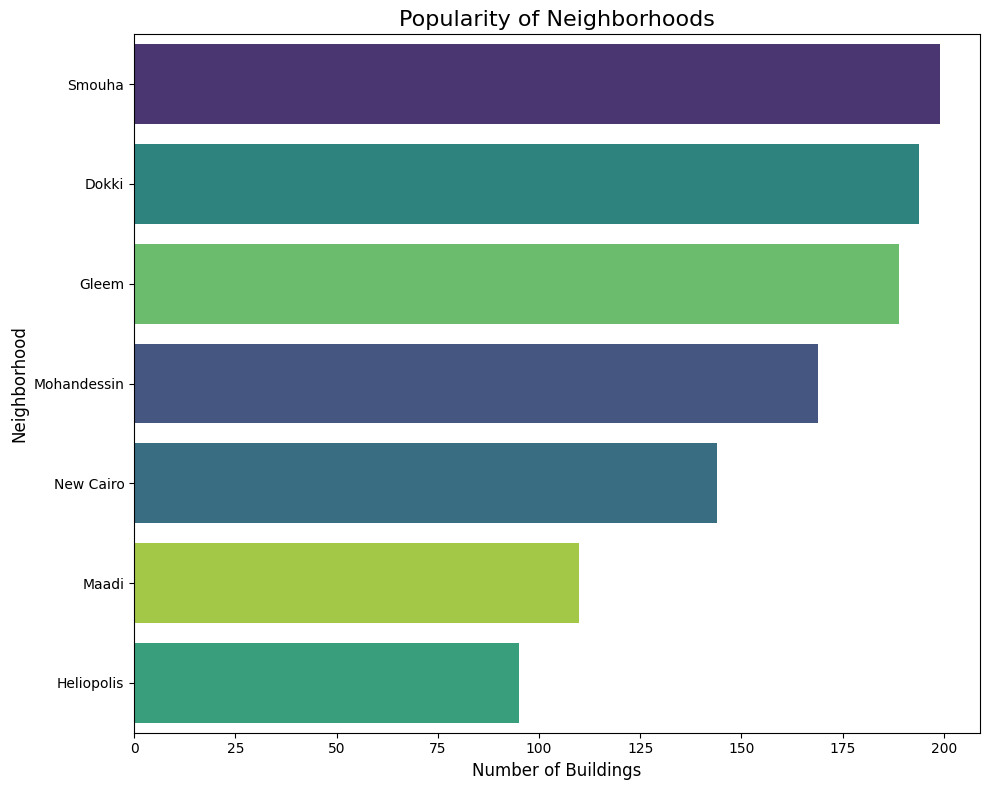

In [16]:
plt.figure(figsize=(10, 8))
sns.countplot(data=df, y='Neighborhood', order=df['Neighborhood'].value_counts().index, palette='viridis', hue='Neighborhood', legend=False)
plt.title('Popularity of Neighborhoods', fontsize=16)
plt.xlabel('Number of Buildings', fontsize=12)
plt.ylabel('Neighborhood', fontsize=12)
plt.tight_layout()
plt.show()

**Answer for Q1:** *the top 3 neighborhoods are Smouha, Dokki and Gleem.*

*Horizontal Bar Chart (specifically, a seaborn.countplot)*

*This chart would be ideal in visualizing the frequency (count) of an item in a categorical variable (such as the Neighborhood). It includes the number of times that each neighborhood is included in the data and it presents it as a bar.*

**Q2:** Show the distribution of the energy consumption of each Building type.

Which type have the widest distribution of energy consumption?

Which (on average) has the highest consumption?.

**Visualization**

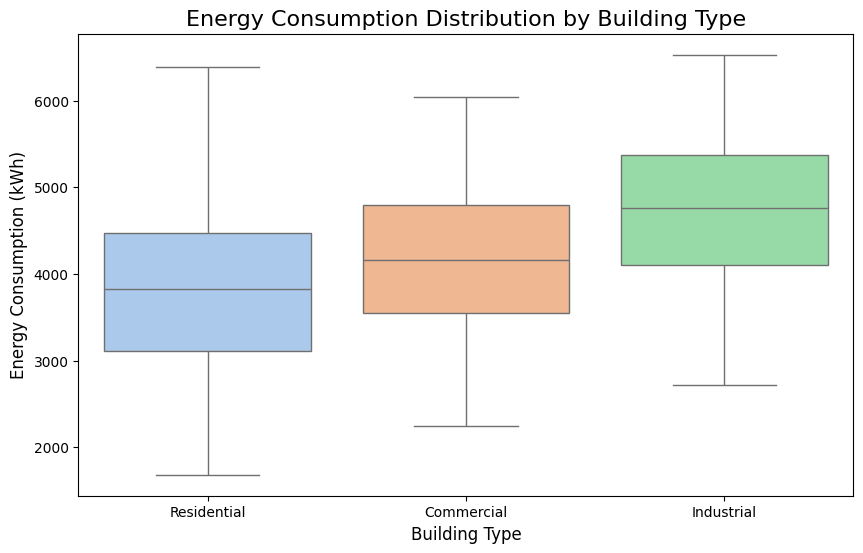

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Building_Type', y='Energy_Consumption(kwh)', palette='pastel', hue='Building_Type', legend=False)
plt.title('Energy Consumption Distribution by Building Type', fontsize=16)
plt.xlabel('Building Type', fontsize=12)
plt.ylabel('Energy Consumption (kWh)', fontsize=12)
plt.show()

**Answer for Q2:** _The type that has the widest distribution of energy consumption is the Residential as it has the longest minimum and maximum whiskers. The Industrial building type has (on average) the highest consumption as it has the highest median compared to the other building types on the box._

*The best tool to use here would be a box plot since it is specifically created to describe and compare the distribution (dispersion) of a numerical metric (such as EnergyConsumption(kwh)) between multiple categorical groups (such as BuildingType).*

**Q3:** How does the building size affect energy consumption?

**Visualization**

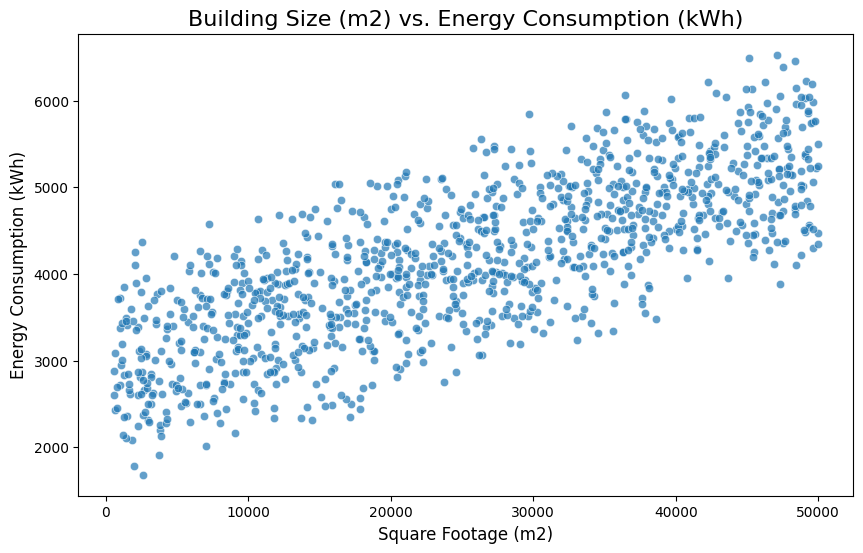

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Square_Footage(m2)', y='Energy_Consumption(kwh)', alpha=0.7)
plt.title('Building Size (m2) vs. Energy Consumption (kWh)', fontsize=16)
plt.xlabel('Square Footage (m2)', fontsize=12)
plt.ylabel('Energy Consumption (kWh)', fontsize=12)
plt.show()

**Answer for Q3:** _As the square footage increases, the energy consumption increases with it (positive correlation)._

*Using a scatterplot in this case is logical as scatterplots project the relationship between any 2 numerical variables.*

**Q4:** Do buildings consume more energy if not maintained frequently?

**Visualization**

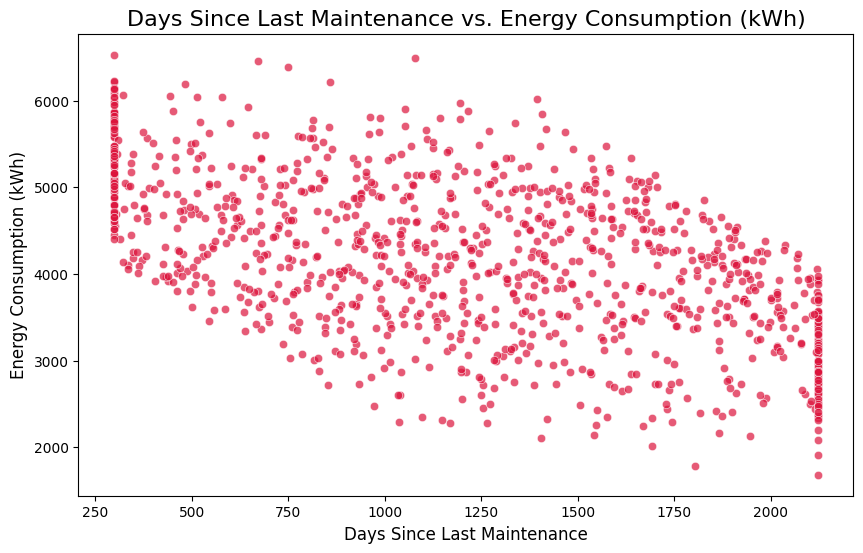

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='days_since_last_maintenance', y='Energy_Consumption(kwh)', alpha=0.7, color='crimson')
plt.title('Days Since Last Maintenance vs. Energy Consumption (kWh)', fontsize=16)
plt.xlabel('Days Since Last Maintenance', fontsize=12)
plt.ylabel('Energy Consumption (kWh)', fontsize=12)
plt.show()

**Answer for Q4:** _The scatterplot shows that there is no correlation between days since last maintenance and energy consumption._

*Using a scatterplot in this case is logical as scatterplots project the relationship between any 2 numerical variables.*

**Q5:** Are all the numerical variables normally distributed, or is there any skewness?

**Visualization**

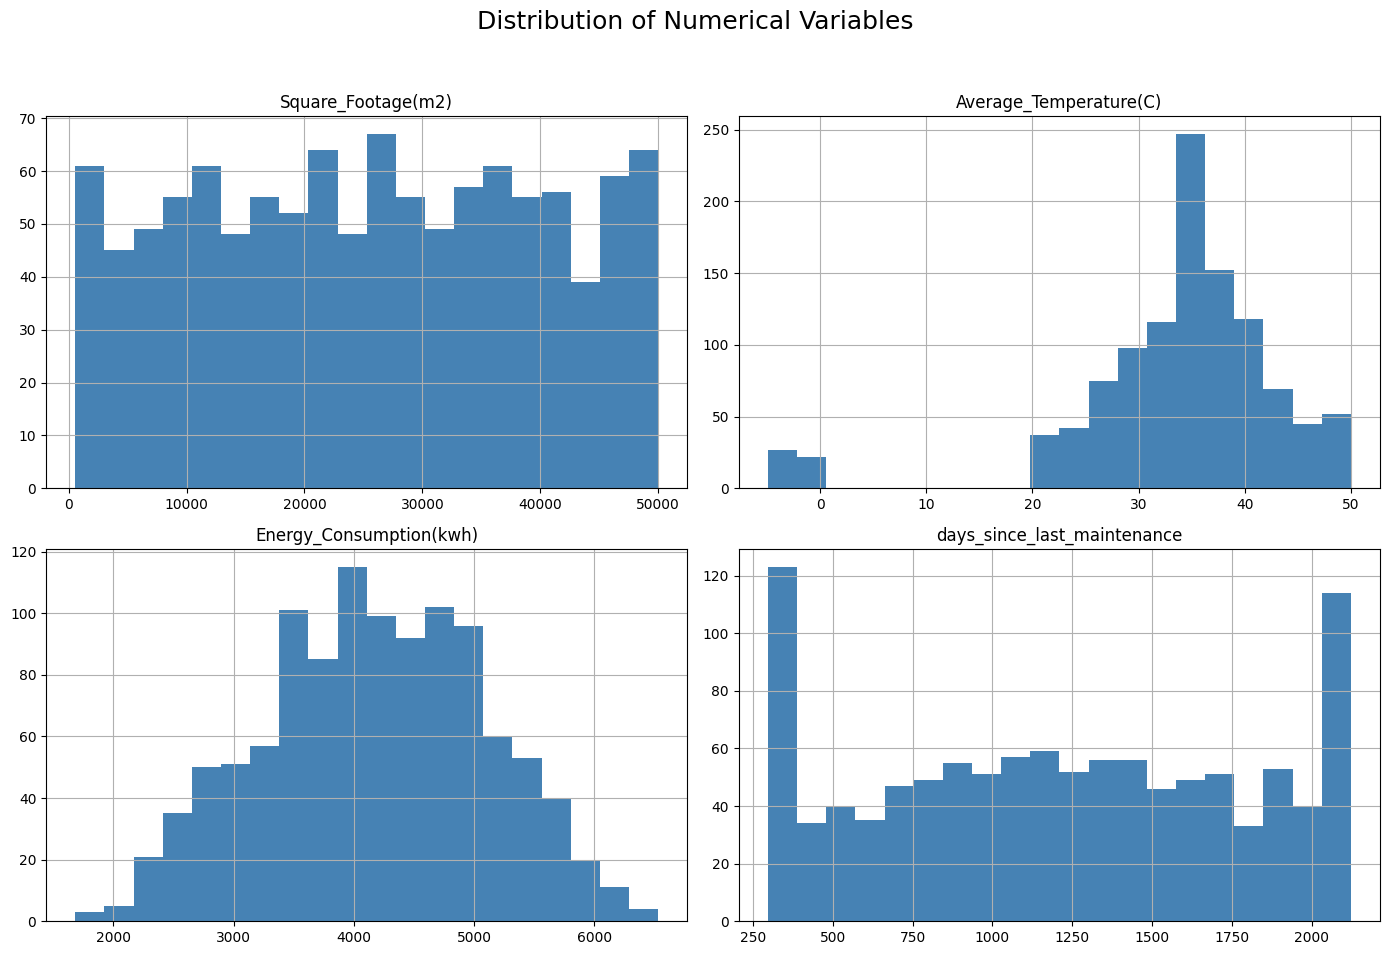

In [20]:
numerical_cols = ['Square_Footage(m2)', 'Average_Temperature(C)', 'Energy_Consumption(kwh)', 'days_since_last_maintenance']
df[numerical_cols].hist(bins=20, figsize=(14, 10), color='steelblue', ec='black')
plt.suptitle('Distribution of Numerical Variables', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

**Answer for Q5:** _They are not all normally distributed, there is skewness in the square footage, days since last maintenance and average temperature histograms. Energy consumption is normally distributed, but average temerature has its data clustered on the right. Square footage shows a uniform distribution which means that all its values are close to each other (same height)._

*We used a histogram in this question since it is the quickest and easy to understand method of viewing the shape of your data which answers directly the question about normality and skew.*

**Q6:** What is multicollinearity? And why is it a problem for linear regression? Does this problem exist in this
dataset?

**Visualization**

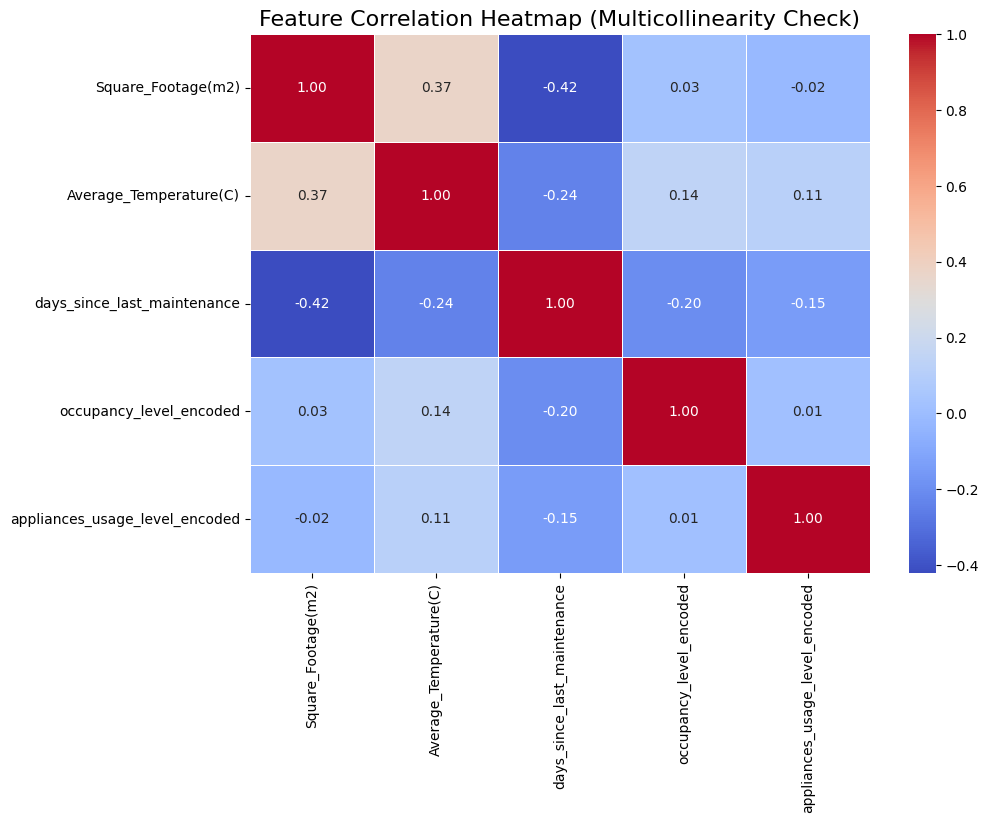

In [21]:
features = ['Square_Footage(m2)', 'Average_Temperature(C)',
            'days_since_last_maintenance', 'occupancy_level_encoded',
            'appliances_usage_level_encoded']

corr_matrix = df[features].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap (Multicollinearity Check)', fontsize=16)
plt.show()

**Answer for Q6:** _Multicollinearity is a regression problem where two or more of your predictor variables (features) are being too much correlated with each other. This is a problem because, when features are highly correlated, the model can't tell which one is actually responsible for the effect on the target variable making the model's coefficients unstable and unreliable. Data is considered highly correlated if correlation values are higher than 0.8 or less than -0.8. This problem does not exist in the dataset as all features are independent. We imlpied that as the highest positive correlation is 0.37 and the highest negative correlation is -0.42, which is not greater that 0.8 or less that -0.8_

*The most efficient and most common visualization that will be effective in answering this question is a Heatmap since its main aim is to show a correlation table.*

## Data Preparation for Modelling

_Apply any additional data preparation steps needed before modelling below. Show/output the changes to the dataset._

In [22]:
nominal_cols = ['Building_Type', 'Governorate', 'Neighborhood', 'day_type']
df_dummies = pd.get_dummies(df[nominal_cols], dtype=int)
df = pd.concat([df, df_dummies], axis=1)
df = df.drop(columns=nominal_cols)
df = df.drop(columns=['Day_of_Week'])

df.head()

,Building_ID,Square_Footage(m2),Average_Temperature(C),Energy_Consumption(kwh),days_since_last_maintenance,occupancy_level_encoded,appliances_usage_level_encoded,Building_Type_Commercial,Building_Type_Industrial,Building_Type_Residential,...,Governorate_Giza,Neighborhood_Dokki,Neighborhood_Gleem,Neighborhood_Heliopolis,Neighborhood_Maadi,Neighborhood_Mohandessin,Neighborhood_New Cairo,Neighborhood_Smouha,day_type_Weekday,day_type_Weekend
0,BLD-1000-UD,7063.0,28.61,2713.95,2123,2,0,0,0,1,...,0,0,0,0,0,0,0,1,1,0
1,BLD-1001-AX,44372.0,35.26,5744.99,1338,2,2,1,0,0,...,1,0,0,0,0,1,0,0,1,0
2,BLD-1002-IH,19255.0,37.88,4101.24,1705,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
3,BLD-1003-HE,13265.0,35.06,3009.14,817,0,2,0,0,1,...,0,1,0,0,0,0,0,0,1,0
4,BLD-1004-XD,13375.0,28.82,3279.17,1169,0,0,1,0,0,...,0,0,0,0,0,0,0,1,1,0


Encoding all text columns into numbers (0'1 ans 1's) using the one hot encoding technique. This technique is used with nominal (no levels or order ex: Cairo, Giza- Giza is not less than Cairo) categoric data.

It takes a single column and divides it into n columns based on the unique values of that column.

For example, if a building type is residential, the building_type_residential column takes a 1 and all other building type columns take a 0.

In [23]:
df = df.drop(columns=['Building_ID'])
df.head()

,Square_Footage(m2),Average_Temperature(C),Energy_Consumption(kwh),days_since_last_maintenance,occupancy_level_encoded,appliances_usage_level_encoded,Building_Type_Commercial,Building_Type_Industrial,Building_Type_Residential,Governorate_Alexandria,...,Governorate_Giza,Neighborhood_Dokki,Neighborhood_Gleem,Neighborhood_Heliopolis,Neighborhood_Maadi,Neighborhood_Mohandessin,Neighborhood_New Cairo,Neighborhood_Smouha,day_type_Weekday,day_type_Weekend
0,7063.0,28.61,2713.95,2123,2,0,0,0,1,1,...,0,0,0,0,0,0,0,1,1,0
1,44372.0,35.26,5744.99,1338,2,2,1,0,0,0,...,1,0,0,0,0,1,0,0,1,0
2,19255.0,37.88,4101.24,1705,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
3,13265.0,35.06,3009.14,817,0,2,0,0,1,1,...,0,1,0,0,0,0,0,0,1,0
4,13375.0,28.82,3279.17,1169,0,0,1,0,0,1,...,0,0,0,0,0,0,0,1,1,0


We drop the building id column as it won't be needed in the data analysis or data modelling steps.

In [24]:
cols_to_drop = [
    'Building_ID',
    'Building_Type', 'Governorate', 'Neighborhood', 'day_type',
    'Day_of_Week', 'Last_Maintenance_Date',
    'Occupancy_Level', 'Appliances_Usage_Level'
]

cols_to_drop_exist = [col for col in cols_to_drop if col in df.columns]
df_model_ready = df.drop(columns=cols_to_drop_exist)

print(df_model_ready.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Square_Footage(m2)              1100 non-null   float64
 1   Average_Temperature(C)          1100 non-null   float64
 2   Energy_Consumption(kwh)         1100 non-null   float64
 3   days_since_last_maintenance     1100 non-null   int64  
 4   occupancy_level_encoded         1100 non-null   int64  
 5   appliances_usage_level_encoded  1100 non-null   int64  
 6   Building_Type_Commercial        1100 non-null   int64  
 7   Building_Type_Industrial        1100 non-null   int64  
 8   Building_Type_Residential       1100 non-null   int64  
 9   Governorate_Alexandria          1100 non-null   int64  
 10  Governorate_Cairo               1100 non-null   int64  
 11  Governorate_Giza                1100 non-null   int64  
 12  Neighborhood_Dokki              11

Select all Columns needed for the linear regression model dropping all text columns.

## Modelling

_Apply the linear regression model below._

In [25]:
X = df_model_ready.drop(columns=['Energy_Consumption(kwh)'])
y = df_model_ready['Energy_Consumption(kwh)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
model = LinearRegression()
model.fit(X_train, y_train)
print("\nModel has been trained successfully.")

Training data shape: (880, 20)
Testing data shape: (220, 20)

Model has been trained successfully.


## Model Evaluation

Evaluate the model you applied.

In [26]:
y_pred = model.predict(X_test)
print("Predictions made on the test set.")

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"  R-squared (R2): {r2:.3f}")
print(f"  Mean Squared Error (MSE): {mse:.3f}")
print(f"  Root Mean Squared Error (RMSE): {rmse:.3f} kWh")


Predictions made on the test set.
  R-squared (R2): 0.944
  Mean Squared Error (MSE): 47929.425
  Root Mean Squared Error (RMSE): 218.928 kWh



Evaluation:

R-squared (R2), or Coefficient of Determination, is a statistical value that relates to the percentage of the variance in the target variable (Energy consumption (kwh)) that is attributed to the model characteristics. It is a score that lies in the range of 0 to 1 with a score of 0 indicating that the model does not explain any of the variability whereas a score of 1 indicates that it explains all the variability. Our high R-squared of 0.944 means that the model has been able to explain 94.4% of the variability in energy consumption in this dataset.

Mean Squared Error (MSE) a value that quantifies the average of the squares of the differences between the actual values and the predicted values of the model. The measure is not very intuitively understood as its units are squared (e.g. 47929 kWh2) and it is hard to imagine it in the real world. It is however a vital ingredient in the computation of the more understandable RMSE.

Root Mean Squared Error (RMSE) is the main indicator of the usefulness of the model. It is the square root of MSE that returns the metric to the original unit of the target variable (kWh2 kWh) back. Considered as the standard deviation of the errors in prediction, it gives information of how the average distance between the predictions and the actual values of the model is. The value of 218.9 kWh indicates that on, an average, a building that has been predicted to consume energy is in error by approximately 219 kWh in our model.

## Conclusion and Recommendations

Comment on the model performance and your findings from model evaluation. State the problems (if any) and suggest possible solutions. Would you recommend this model for an electrcity company aiming to estimate the energy levels of each building?

**Answer**: your answer here.

The regression linear model that was designed to forecast building energy consumption fit well the data with an R-squared (R2) of 0.944. This means that the features incorporated in the model (size of the building, average temperature, building type, occupancy, etc) can explain about 94.4% of the variation in energy consumption. Root Mean Squared Error (RMSE) was used to determine the predictive accuracy of the model and produced a value of 218.9 kWh. This implies that the model will on average give inaccurate predictions in terms of the actual energy consumption by approximately 219 kWh.

Yes I would recommed this model for an electricity company as the numbers calculated ensure that the model would perform accurately.